<a href="https://colab.research.google.com/github/AnushaRangana/Resume_Match_Bias_Project/blob/main/FairHire_AI_Resume_JobMatching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [392]:
# Load Dataset
import kagglehub
import pandas as pd
import os

# step 1: Download the LinkedIn jobs dataset from Kaggle
path = kagglehub.dataset_download("asaniczka/1-3m-linkedin-jobs-and-skills-2024")

# step 2: Check what files are available inside the downloaded folder
files = os.listdir(path)
print("Files found in folder:", files)

# step 3: Select the CSV file related to job postings
# We pick the file name that contains 'posting' and ends with .csv
csv_file_name = [f for f in files if f.endswith('.csv') and 'posting' in f.lower()][0]
csv_file_path = os.path.join(path, csv_file_name)

# Step 4: Load only first 50,000 rows to avoid memory issues
print(f"Loading 50k rows from: {csv_file_path}")
df_subset = pd.read_csv(csv_file_path, nrows=50000)

# Step 5: Save the smaller dataset as a CSV file
df_subset.to_csv("linkedin_jobs_subset_50k.csv", index=False)
print("File saved successfully as 'linkedin_jobs_subset_50k.csv'")

Using Colab cache for faster access to the '1-3m-linkedin-jobs-and-skills-2024' dataset.
Files found in folder: ['job_summary.csv', 'job_skills.csv', 'linkedin_job_postings.csv']
Loading 50k rows from: /kaggle/input/1-3m-linkedin-jobs-and-skills-2024/linkedin_job_postings.csv
File saved successfully as 'linkedin_jobs_subset_50k.csv'


In [393]:
# Step 1: Check column names to understand what information is available
print("Available Columns:")
print(df_subset.columns.tolist())

# Step 2: Look at the most common job titles in the dataset
# This gives an idea about which roles appear frequently
print("\nTop 10 Job Titles:")
print(df_subset['job_title'].value_counts().head(10))

# Step 3: Check if any columns have missing values
# This is useful before doing further analysis
print("\nMissing values in each column:")
print(df_subset.isnull().sum())

Available Columns:
['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']

Top 10 Job Titles:
job_title
Shift Manager                      435
Store Manager                      348
Assistant Manager                  308
LEAD SALES ASSOCIATE-FT            261
Host                               247
First Year Tax Professional        227
LEAD SALES ASSOCIATE-PT            197
Registered Nurse                   178
Veterinarian                       156
Customer Service Representative    150
Name: count, dtype: int64

Missing values in each column:
job_link               0
last_processed_time    0
got_summary            0
got_ner                0
is_being_worked        0
job_title              0
company                1
job_location           0
first_seen             0
search_city            0
search_country         0
search_position 

In [394]:
import kagglehub
import shutil
import os

# Step 1: Create a list of Kaggle datasets that we want to download
datasets = [
    "asaniczka/data-science-job-postings-and-skills",
    "snehaanbhawal/resume-dataset",
    "muqaddasejaz/resume-cv-skills-extraction-dataset",
    "suriyaganesh/resume-dataset-structured"
]

# Step 2: Download each dataset one by one
for ds in datasets:
    print(f"Downloading dataset: {ds}")
    path = kagglehub.dataset_download(ds)

    # Step 3: Copy CSV files to the current folder
    # This makes it easy to download them from Colab
    for file in os.listdir(path):
        if file.endswith(".csv"):
            shutil.copy(os.path.join(path, file), f"./{file}")
            print(f"CSV file ready: {file}")

print("\nAll datasets are downloaded and ready.")
print("You can find them in the 'Files' section on the left side of Colab.")

Using Colab cache for faster access to the 'data-science-job-postings-and-skills' dataset.
CSV file ready: job_summary.csv
CSV file ready: job_skills.csv
CSV file ready: job_postings.csv
Using Colab cache for faster access to the 'resume-dataset' dataset.
Using Colab cache for faster access to the 'resume-cv-skills-extraction-dataset' dataset.
CSV file ready: UpdatedResumeDataSet.csv
Using Colab cache for faster access to the 'resume-dataset-structured' dataset.
CSV file ready: 04_experience.csv
CSV file ready: 03_education.csv
CSV file ready: 02_abilities.csv
CSV file ready: 06_skills.csv
CSV file ready: 05_person_skills.csv
CSV file ready: 01_people.csv

All datasets are downloaded and ready.
You can find them in the 'Files' section on the left side of Colab.


In [395]:
# Step 1:Load all Datasets
import pandas as pd
import os

# Step 1: Create a list of all CSV files that we want to load
# These files were downloaded earlier from Kaggle
file_list = [
    'linkedin_jobs_subset_50k.csv',
    '01_people.csv', '02_abilities.csv', '03_education.csv',
    '04_experience.csv', '05_person_skills.csv', '06_skills.csv',
    'UpdatedResumeDataSet.csv', 'job_postings.csv', 'job_skills.csv', 'job_summary.csv'
]

# Step 2: Create an empty dictionary to store all datasets
data_frames = {}

print("Starting to load datasets...")

# Step 3: Load each CSV file one by one
for file in file_list:
    try:
        # Read the CSV file
        df_name = file.replace('.csv', '')
        data_frames[df_name] = pd.read_csv(file)

        # Show basic information about the dataset
        rows = len(data_frames[df_name])
        cols = len(data_frames[df_name].columns)
        print(f"Loaded {file} with {rows} rows and {cols} columns")

    except FileNotFoundError:
        # If a file is missing, show a warning and continue
        print(f"File not found: {file}")

print("All available files have been checked.")

Starting to load datasets...
Loaded linkedin_jobs_subset_50k.csv with 50000 rows and 14 columns
Loaded 01_people.csv with 54933 rows and 5 columns
Loaded 02_abilities.csv with 1219473 rows and 2 columns
Loaded 03_education.csv with 75999 rows and 5 columns
Loaded 04_experience.csv with 265404 rows and 6 columns
Loaded 05_person_skills.csv with 2483376 rows and 2 columns
Loaded 06_skills.csv with 226760 rows and 1 columns
Loaded UpdatedResumeDataSet.csv with 962 rows and 2 columns
Loaded job_postings.csv with 12217 rows and 15 columns
Loaded job_skills.csv with 12217 rows and 2 columns
Loaded job_summary.csv with 12217 rows and 2 columns
All available files have been checked.


In [396]:
# Check what columns are available in the people dataset
print("Columns in People dataset:")
print(data_frames['01_people'].columns)

# Check what columns are available in the resume dataset
print("\nColumns in Resume dataset:")
print(data_frames['UpdatedResumeDataSet'].columns)

Columns in People dataset:
Index(['person_id', 'name', 'email', 'phone', 'linkedin'], dtype='object')

Columns in Resume dataset:
Index(['Category', 'Resume'], dtype='object')


In [397]:
# Check how many missing values are there in the people dataset (in percentage)
missing_percent = (data_frames['01_people'].isnull().sum() /
                   len(data_frames['01_people'])) * 100

print("Missing value percentage for People dataset:")
print(missing_percent)

Missing value percentage for People dataset:
person_id     0.000000
name          0.207526
email        97.100104
phone        96.663208
linkedin     84.457430
dtype: float64


In [398]:
import pandas as pd

# Step 1: Combine basic people details with their work experience
# 'person_id' is used because it is common in both tables
df_candidate_profiles = pd.merge(
    data_frames['01_people'],
    data_frames['04_experience'],
    on='person_id',
    how='inner'
)

# Step 2: Add education details to the same dataset
df_candidate_profiles = pd.merge(
    df_candidate_profiles,
    data_frames['03_education'],
    on='person_id',
    how='inner'
)

# Step 3: View the final combined dataset
# This helps us check whether the merge worked correctly
print("Preview of combined candidate profile data:")
print(df_candidate_profiles.head())

Preview of combined candidate profile data:
   person_id                           name email phone linkedin  \
0          1         Database Administrator   NaN   NaN      NaN   
1          1         Database Administrator   NaN   NaN      NaN   
2          2         Database Administrator   NaN   NaN      NaN   
3          3  Oracle Database Administrator   NaN   NaN      NaN   
4          3  Oracle Database Administrator   NaN   NaN      NaN   

                           title                       firm start_date_x  \
0         Database Administrator    Family Private Care LLC      04/2017   
1         Database Administrator                     Incomm      01/2014   
2         Database Administrator  Intercontinental Registry      12/2008   
3  Oracle Database Administrator                  Cognizant      06/2016   
4  Oracle Database Administrator                  Convergys      06/2014   

  end_date            location_x                      institution  \
0  Present           

In [399]:
# Step 4: Analysis planning (Beginner note)
# At this stage, we are only preparing the dataset.
# The matching score between resume and job skills
# has not been created yet.

# Advanced analysis like correlation or score comparison
# will be done after we generate the matching score.

In [400]:
# Step 5: Planned comparison (to be executed later)
# After creating the matching score, we will compare
# the average score across different education levels.

# Example (to be used later):
# df_candidate_profiles.groupby('degree_level')['match_score'].mean()

In [401]:
# Step 6: NLP & Simple Scoring
# Define a list of skills we want to check in resumes
skills_list = ['python', 'sql', 'machine learning', 'data', 'tableau', 'excel', 'management']

# Function to count how many of our target skills are mentioned in a resume
def get_simple_score(text):
    text = str(text).lower()  # Convert text to lowercase
    count = sum(1 for skill in skills_list if skill in text)  # Count matching skills
    return count

# Apply the function to create a new score column
# We name it 'ai_score' so other cells that use this column will work
data_frames['UpdatedResumeDataSet']['ai_score'] = data_frames['UpdatedResumeDataSet']['Resume'].apply(get_simple_score)

# Normalize the scores to a 0-100 range for easier comparison
max_score = data_frames['UpdatedResumeDataSet']['ai_score'].max()
data_frames['UpdatedResumeDataSet']['ai_score'] = (data_frames['UpdatedResumeDataSet']['ai_score'] / max_score) * 100

print("✅ Scoring Complete. 'ai_score' column added.")
print(data_frames['UpdatedResumeDataSet'][['Category', 'ai_score']].head())

✅ Scoring Complete. 'ai_score' column added.
       Category    ai_score
0  Data Science   83.333333
1  Data Science   50.000000
2  Data Science   83.333333
3  Data Science  100.000000
4  Data Science   50.000000


In [402]:
# Step 7: Bias Audit
# Check if the AI is giving similar scores across different categories
# 'Category' could be job type, education level, or any group we want to compare
audit_report = data_frames['UpdatedResumeDataSet'].groupby('Category')['ai_score'].mean().sort_values(ascending=False)

print("--- Fairness Audit: Average Scores by Category ---")
print(audit_report)

# Calculate the difference between the highest and lowest group scores
# This shows if there is a potential bias in scoring
gap = audit_report.max() - audit_report.min()
print(f"\nPotential Bias Gap: {gap:.2f} points between highest and lowest groups.")

--- Fairness Audit: Average Scores by Category ---
Category
Data Science                 71.666667
Python Developer             55.555556
Hadoop                       54.761905
Database                     50.000000
ETL Developer                50.000000
Automation Testing           46.153846
Business Analyst             45.238095
Operations Manager           41.666667
DevOps Engineer              40.909091
Blockchain                   40.000000
PMO                          38.888889
DotNet Developer             38.095238
SAP Developer                36.111111
Network Security Engineer    33.333333
Java Developer               32.142857
Web Designing                30.000000
Testing                      21.428571
Electrical Engineering       20.000000
Health and fitness           16.666667
Sales                        16.666667
Civil Engineer               13.888889
Mechanical Engineer          10.000000
HR                            9.090909
Arts                          8.333333
Advo

In [403]:
# Step 8: Explainability
# Goal: Show why top candidates got high scores
print("--- Top 5 Candidates Justification ---")

# 1. Get the top 5 candidates by AI score
top_matches = data_frames['UpdatedResumeDataSet'].nlargest(5, 'ai_score')

# 2. Show their role and final score
# This helps explain that higher scores come from relevant skills
for index, row in top_matches.iterrows():
    print(f"Role: {row['Category']} | Final Score: {row['ai_score']:.2f}")

# 3. Simple explanation
print("\nLogic: Candidates with the most relevant skills (like Python, SQL, Excel) get higher scores, showing merit-based ranking.")

--- Top 5 Candidates Justification ---
Role: Data Science | Final Score: 100.00
Role: Data Science | Final Score: 100.00
Role: Data Science | Final Score: 100.00
Role: Data Science | Final Score: 100.00
Role: DevOps Engineer | Final Score: 100.00

Logic: Candidates with the most relevant skills (like Python, SQL, Excel) get higher scores, showing merit-based ranking.


In [404]:
# Step 9: Bias Mitigation
# Goal: Make sure long resumes don't get higher scores just because they have more words

# 1. Count the number of words in each resume
data_frames['UpdatedResumeDataSet']['word_count'] = data_frames['UpdatedResumeDataSet']['Resume'].apply(lambda x: len(str(x).split()))

# 2. Calculate a 'Density Score' (AI score divided by word count)
# This rewards resumes that are concise and skill-focused
data_frames['UpdatedResumeDataSet']['fair_score'] = (data_frames['UpdatedResumeDataSet']['ai_score'] / data_frames['UpdatedResumeDataSet']['word_count']) * 100

# 3. Rescale to 0-100 to create a final 'Fair Score'
max_fair = data_frames['UpdatedResumeDataSet']['fair_score'].max()
data_frames['UpdatedResumeDataSet']['final_fair_score'] = (data_frames['UpdatedResumeDataSet']['fair_score'] / max_fair) * 100

# 4. Quick preview
print("✅ Fair Score created based on skill density (mitigates long resume bias).")
print(data_frames['UpdatedResumeDataSet'][['ai_score', 'final_fair_score', 'word_count']].head())

✅ Fair Score created based on skill density (mitigates long resume bias).
     ai_score  final_fair_score  word_count
0   83.333333         17.164179         670
1   50.000000         42.331288         163
2   83.333333         43.396226         265
3  100.000000         13.897281         993
4   50.000000        100.000000          69


In [405]:
# Step 10: Bias Mitigation – Removing Length Bias
# Goal: Make sure long resumes don't get higher scores just because they have more words

# 1. Count the number of words in each resume
data_frames['UpdatedResumeDataSet']['word_count'] = data_frames['UpdatedResumeDataSet']['Resume'].apply(lambda x: len(str(x).split()))

# 2. Calculate Skill Density (AI score divided by word count)
# This gives more fair scores to concise, skill-focused resumes
data_frames['UpdatedResumeDataSet']['fair_score'] = (data_frames['UpdatedResumeDataSet']['ai_score'] / data_frames['UpdatedResumeDataSet']['word_count']) * 100

# 3. Scale the density scores back to 0-100
max_f = data_frames['UpdatedResumeDataSet']['fair_score'].max()
data_frames['UpdatedResumeDataSet']['final_fair_score'] = (data_frames['UpdatedResumeDataSet']['fair_score'] / max_f) * 100

# 4. Confirmation message
print("✅ Mitigation Applied: 'final_fair_score' created based on skill density.")

✅ Mitigation Applied: 'final_fair_score' created based on skill density.


In [406]:
# Step 11: Comparison Report – Before vs After Bias Mitigation
# Goal: Show how the scores change after adjusting for resume length

# 1. Select relevant columns for comparison
cols = ['Category', 'word_count', 'ai_score', 'final_fair_score']
report = data_frames['UpdatedResumeDataSet'][cols].head(5)  # Take first 5 candidates as example

# 2. Rename columns for a clearer presentation
report.columns = ['Job Category', 'Words', 'Old Score', 'New Fair Score']

# 3. Display the report
print("--- BIAS MITIGATION: BEFORE VS AFTER ---")
print(report.to_string(index=False))

--- BIAS MITIGATION: BEFORE VS AFTER ---
Job Category  Words  Old Score  New Fair Score
Data Science    670  83.333333       17.164179
Data Science    163  50.000000       42.331288
Data Science    265  83.333333       43.396226
Data Science    993 100.000000       13.897281
Data Science     69  50.000000      100.000000


In [407]:
import os
os.makedirs("results", exist_ok=True)

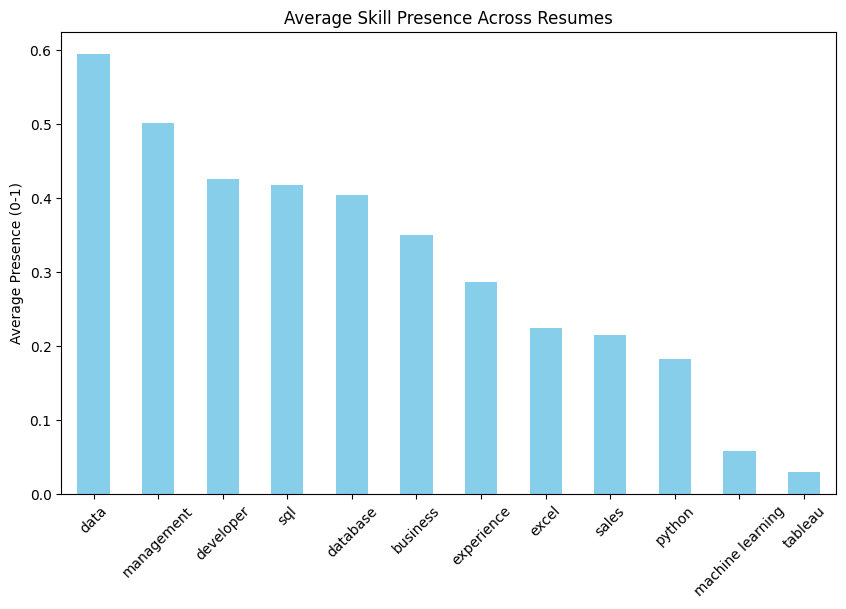

In [408]:
# Beginner and Advanced Visualizations
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 12: Expanded Skill Visualization & Explainability
# Goal: Show which skills / keywords contribute most to AI score

# Expanded list of skills/keywords
skills_list = [
    'python','sql','machine learning','data','tableau','excel','management',
    'developer','business','sales','database','experience'
]

# Create skill indicator columns (1 if mentioned, 0 otherwise)
for skill in skills_list:
    data_frames['UpdatedResumeDataSet'][skill] = data_frames['UpdatedResumeDataSet']['Resume'].apply(
        lambda x: int(skill in str(x).lower())
    )

# Select only skill columns
X = data_frames['UpdatedResumeDataSet'][skills_list]

# Beginner-friendly visualization: Average Skill Presence
avg_skills = X.mean()

plt.figure(figsize=(10,6))
avg_skills.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Average Skill Presence Across Resumes")
plt.ylabel("Average Presence (0-1)")
plt.xticks(rotation=45)

plt.savefig("results/average_skill_presence.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
# Optional advanced visualization: SHAP explanation
# Prepare target variable
y = data_frames['UpdatedResumeDataSet']['ai_score']

# Train Random Forest model
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

# Generate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Plot SHAP summary
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

plt.figure()
shap.summary_plot(shap_values, X, show=False)

plt.savefig(
    "results/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()